In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [19]:
cancer = load_breast_cancer()

# Use only two features for visualization
X = pd.DataFrame(
    cancer.data[:, :2],
    columns=cancer.feature_names[:2]
)

y = cancer.target

In [20]:
print(cancer.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [21]:
print(cancer.data.shape)

(569, 30)


In [22]:
cancer.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
linear_model = SVC(kernel='linear', random_state=42)
rbf_model = SVC(kernel='rbf', random_state=42)


In [26]:
linear_model.fit(X_train_scaled, y_train)
rbf_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [27]:
linear_pred = linear_model.predict(X_test_scaled)
rbf_pred = rbf_model.predict(X_test_scaled)

In [28]:

print("********** LINEAR SVM **********")


print("Accuracy:",
      accuracy_score(y_test, linear_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, linear_pred))

print("\nClassification Report")
print(classification_report(
    y_test,
    linear_pred,
    target_names=cancer.target_names
))

********** LINEAR SVM **********
Accuracy: 0.9035087719298246

Confusion Matrix
[[36  7]
 [ 4 67]]

Classification Report
              precision    recall  f1-score   support

   malignant       0.90      0.84      0.87        43
      benign       0.91      0.94      0.92        71

    accuracy                           0.90       114
   macro avg       0.90      0.89      0.90       114
weighted avg       0.90      0.90      0.90       114



In [15]:
print("********** RBF SVM **********")

print("Accuracy:",
      accuracy_score(y_test, rbf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rbf_pred))

print("\nClassification Report")
print(classification_report(
    y_test,
    rbf_pred,
    target_names=cancer.target_names
))

********** RBF SVM **********
Accuracy: 0.9210526315789473

Confusion Matrix
[[38  5]
 [ 4 67]]

Classification Report
              precision    recall  f1-score   support

   malignant       0.90      0.88      0.89        43
      benign       0.93      0.94      0.94        71

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.92       114
weighted avg       0.92      0.92      0.92       114



In [ ]:
print("\nClassification Report")
print(classification_report(
    y_test,
    linear_pred,
    target_names=cancer.target_names
))


Classification Report
              precision    recall  f1-score   support

   malignant       0.90      0.84      0.87        43
      benign       0.91      0.94      0.92        71

    accuracy                           0.90       114
   macro avg       0.90      0.89      0.90       114
weighted avg       0.90      0.90      0.90       114



In [35]:
def plot_boundary(model, title):

    x_min = X_train_scaled[:,0].min() - 1
    x_max = X_train_scaled[:,0].max() + 1

    y_min = X_train_scaled[:,1].min() - 1
    y_max = X_train_scaled[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,6))

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(
        X_train_scaled[:,0],
        X_train_scaled[:,1],
        c=y_train,
        edgecolors='k'
    )

    # Support vectors
    plt.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=120,
        facecolors='none',
        edgecolors='red',
        linewidths=2,
        label='Support Vectors'
    )

    plt.xlabel(cancer.feature_names[0])
    plt.ylabel(cancer.feature_names[1])

    plt.title(title)
    plt.legend()

    plt.show()


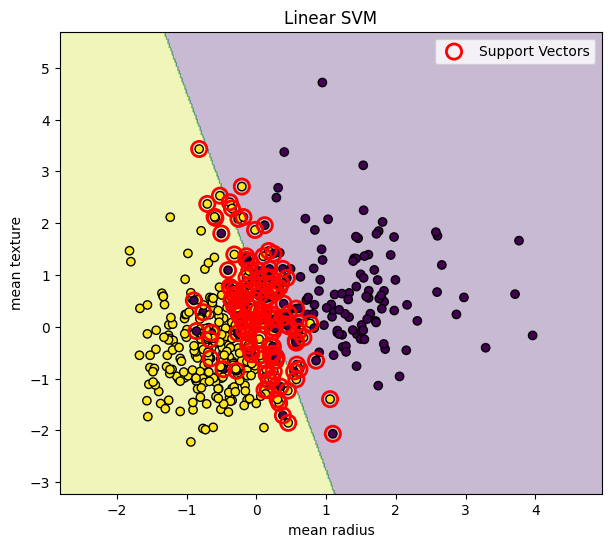

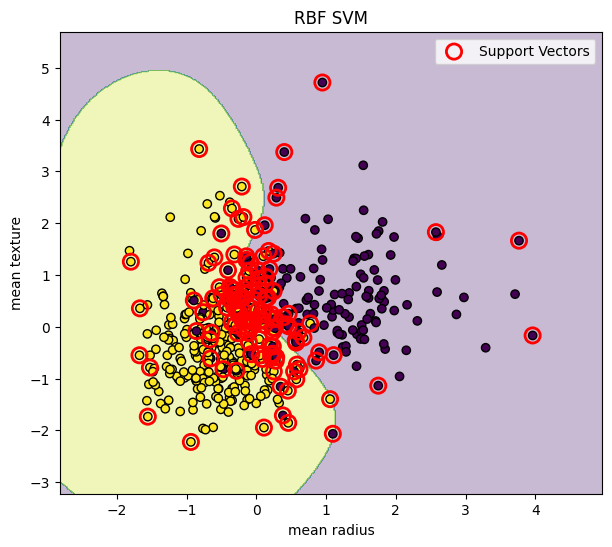

In [36]:
plot_boundary(linear_model, "Linear SVM")

plot_boundary(rbf_model, "RBF SVM")